#Day 24 Regularisasi : Lasso dan Ridge

Regresi linear biasa bisa **overfit** atau menghasilkan koefisien yang tidak stabil saat fitur banyak/berkorelasi. **Regularisasi** menambah "penalti" pada koefisien agar model lebih sederhana & tahan banting. Kita pelajari dua jenis: **Ridge** (L2) dan **Lasso** (L1).

> 🎯 **Tujuan Pembelajaran**
> - Memahami kenapa perlu **standardisasi** sebelum regularisasi.
> - Melatih **Ridge** & **Lasso**, membandingkannya dengan **Linear** biasa.
> - Melihat efek **alpha** (kekuatan penalti) lewat loop.
> - Membuktikan **Lasso menyeleksi fitur** (sebagian koefisien jadi 0).

## Tentang Dataset

**Boston Housing** — data harga rumah di kota Boston beserta atribut lingkungannya.

- **Sumber:** [Kaggle — fedesoriano/the-boston-houseprice-data](https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data)
- **Jumlah data:** 506 baris × 14 kolom

| Kolom | Arti |
|-------|------|
| `RM` | Rata-rata jumlah kamar per rumah |
| `LSTAT` | % penduduk berstatus ekonomi rendah |
| `PTRATIO` | Rasio murid : guru |
| `CRIM` | Tingkat kriminalitas |
| `NOX` | Konsentrasi polusi (NOx) |
| `MEDV` | **Harga median rumah (ribuan USD) — target** |

(Kolom lain: ZN, INDUS, CHAS, AGE, DIS, RAD, TAX, B.)

##Import Library

- **scikit-learn** → `Ridge`, `Lasso`, `LinearRegression`, `StandardScaler`, metrik.
- **pandas/numpy/seaborn/matplotlib** → olah data & grafik.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## Import Dataset

In [4]:
!pip install kaggle
!kaggle datasets download -d fedesoriano/the-boston-houseprice-data
!unzip the-boston-houseprice-data.zip

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data
License(s): copyright-authors
100% 12.3k/12.3k [00:00<00:00, 39.3MB/s]

Archive:  the-boston-houseprice-data.zip
  inflating: boston.csv              


## Eksplorasi Awal

In [5]:
df = pd.read_csv('boston.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [9]:
df.isnull().sum().sum()

np.int64(0)

Interpretasi:
- Semua fitur numerik dengan skala berbeda-beda.
- 506 baris, 0 nilai hilang (total missing = 0). Data siap diolah.
- Harga rumah (`MEDV`) berkisar 5–50 ribu USD. Skala antar fitur sangat berbeda (mis. `TAX` ratusan, `NOX` < 1) — ini alasan KNN butuh standardisasi.
- Perhatikan skala sangat berbeda — TAX ratusan, NOX < 1. Regularisasi menghukum besar koefisien, jadi standardisasi wajib supaya penalti adil ke semua fitur.

##Eksplorasi Data Analisis dan Visualisasi

### a) Heatmap Korelarasi

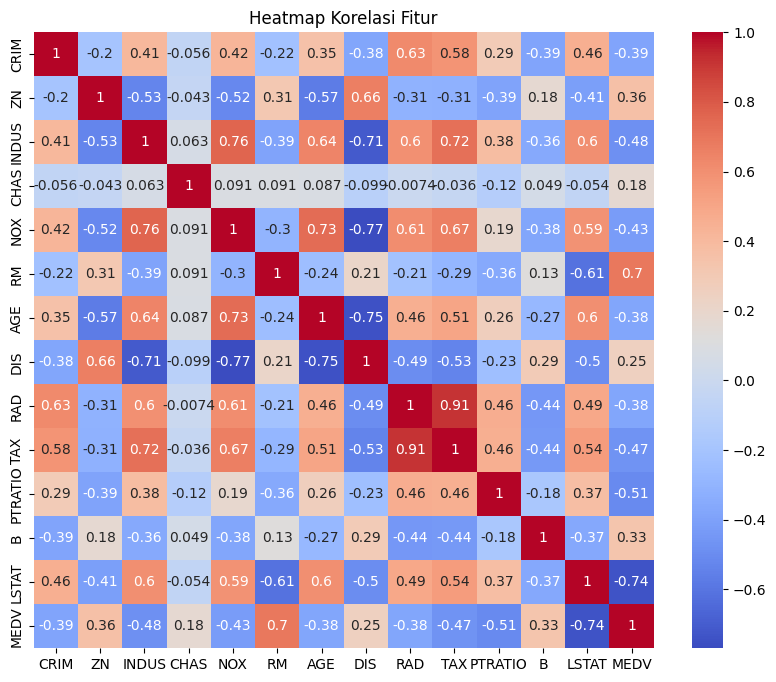

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur')
plt.show()

Interpretasi:
- `RM` mempunyain korelasi positif kuat dengan `MEDV`
- `LSTAT`(status ekonomi rendah) mempunyai kolerasi negatif kuat dengan `MEDV`,
- Beberapa fitur saling berkorelasi (mis. `RAD` & `TAX`,
`NOX` & `INDUS`). Korelasi antar fitur (multikolinearitas) membuat koefisien linear biasa tidak stabil — di sinilah regularisasi membantu.

### b) Kolerasi feature dengan target Y ( MEDV )

/tmp/ipykernel_644/3399580081.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(corr_y[i], i, round(corr_y[i], 2))


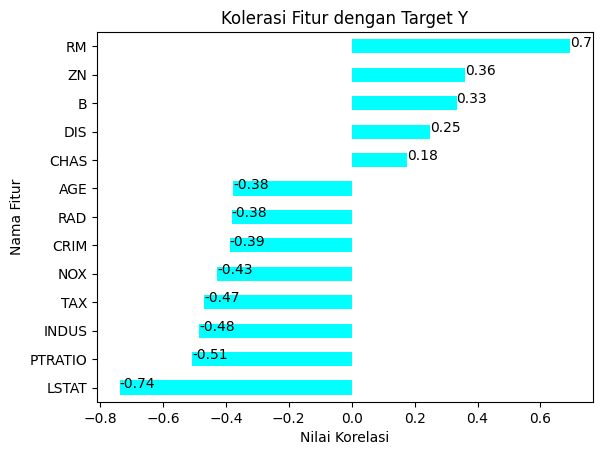

In [13]:
corr_y = df.corr()["MEDV"].drop("MEDV").sort_values()
corr_y.plot(kind="barh", color="cyan")
plt.title("Kolerasi Fitur dengan Target Y")
for i in range(len(corr_y)):
    plt.text(corr_y[i], i, round(corr_y[i], 2))
plt.xlabel("Nilai Korelasi")
plt.ylabel("Nama Fitur")
plt.show()



Interpretasi:
- Terdapat korelasi positif yang kuat antara jumlah kamar (RM) dan harga rumah (MEDV) (0.7). Semakin banyak rata-rata jumlah kamar pada suatu rumah (RM), semakin tinggi pula harga median rumah tersebut (MEDV)
- Terdapat korelasi negatif yang kuat antara kedua variabel ini(-0,74). Semakin tinggi persentase penduduk berstatus ekonomi rendah di suatu kawasan (LSTAT), maka harga median rumah di kawasan tersebut (MEDV) cenderung semakin murah/rendah.

### C) Distribusi Target Y

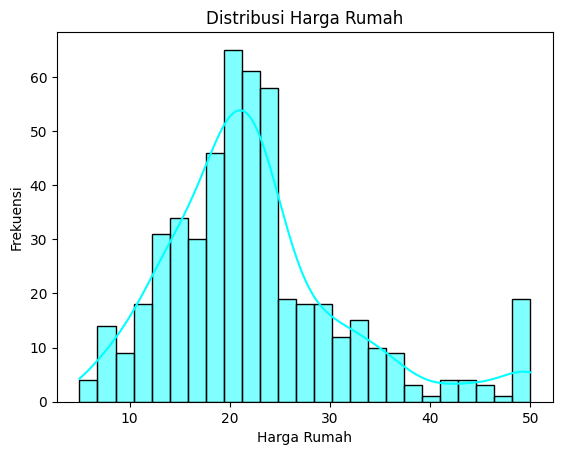

In [14]:
sns.histplot(df['MEDV'],
             bins=25,
             kde=True,
             color="cyan")
plt.title('Distribusi Harga Rumah')
plt.xlabel('Harga Rumah')
plt.ylabel('Frekuensi')
plt.show()

Interpretasi:
- Distribusi agak miring kanan dengan lonjakan di nilai 50
(harga di-*cap*). Mayoritas rumah berharga 17–25 ribu USD.

## Preprocessing - Split & Standarisasi

- Pisahkan target dengan fitur
- Bagi data 80/20.
- Lalu **standardisasi** fitur (rata-rata 0, std 1).

In [15]:
X = df.drop(columns=['MEDV'])
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(404, 13)
(102, 13)


> 🔑 **Anti-bocor:**
  - Informasi Penting sebelum  `fit_transform`

  - perhatikan polanya — `fit_transform` di **data latih**, lalu

  - `transform` saja di **data uji**. Kalau scaler di-`fit` pada seluruh data *sebelum* split,

  - informasi data uji "bocor" ke pelatihan dan skor jadi terlalu optimistis.
  
  - Pola ini berlaku untuk semua langkah preprocessing yang "belajar" dari data (scaling, imputasi, encoding).

## Modeling - Linear Regression VS Penalti ( Ridge & Lasso )

In [29]:
def metrik(model):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    return{
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    }

In [44]:
result = {
    "Linear": metrik(LinearRegression()),
    "Ridge, (a=1)": metrik(Ridge(alpha=1)),
    "Lasso, (a=1)": metrik(Lasso(alpha=1, max_iter=10000))
}

In [47]:
pd.DataFrame(result).T.sort_values(by="R2", ascending=False).round(3)

,R2,MAE,MSE,RMSE
Linear,0.669,3.189,24.291,4.929
"Ridge, (a=1)",0.668,3.186,24.313,4.931
"Lasso, (a=1)",0.624,3.474,27.578,5.251


Interpretasi
1. Penjelasan Metrik Evaluasi
    - $R^2$ (R-Squared): Menunjukkan seberapa besar variasi target (harga rumah) yang dapat dijelaskan oleh model. Nilai yang lebih tinggi (mendekati 1.0) menandakan model yang lebih baik.
    - MAE (Mean Absolute Error): Rata-rata selisih absolut antara nilai prediksi dan nilai aktual. Nilai yang lebih kecil menunjukkan akurasi yang lebih tinggi.
    - MSE (Mean Squared Error) & RMSE (Root Mean Squared Error): Mengukur besar error kuadrat dan akar rata-rata error kuadrat. Memberikan penalti lebih besar pada error yang tinggi (outlier). Nilai yang lebih kecil menandakan model yang lebih konsisten.
  
2. Perbandingan Performa Ketiga Model
    - Linear Regression & Ridge Regression (Alpha = 1) — Performa Terbaik dan Hampir Identik:
      - Kedua model ini menghasilkan nilai $R^2$ tertinggi yaitu 0.669 (untuk Linear) dan 0.668 (untuk Ridge), yang berarti keduanya mampu menjelaskan sekitar 66.8% - 66.9% variasi data.
      - Nilai error mereka juga merupakan yang paling rendah di antara ketiganya (MAE sekitar 3.18 dan RMSE sekitar 4.93).
      - Catatan Analitis: Nilai Ridge yang hampir sama persis dengan Linear Regression menunjukkan bahwa parameter alpha = 1 tidak memberikan penalti yang terlalu agresif pada koefisien, sehingga model Ridge berperilaku sangat mirip dengan regresi linier standar.
      
    - Lasso Regression (Alpha = 1) — Performa Paling Rendah:
      - Model Lasso mencatat performa terburuk pada eksperimen ini, dengan penurunan $R^2$ menjadi 0.624 (hanya mampu menjelaskan 62.4% variasi data).
      - Error-nya pun meningkat secara signifikan, dengan MAE naik menjadi 3.474 dan RMSE menjadi 5.251.
      - Catatan Analitis: Penurunan performa ini mengindikasikan bahwa nilai alpha = 1 pada Lasso terlalu besar (over-regularization). Penalti L1 pada Lasso kemungkinan telah memangkas atau membuat koefisien dari fitur-fitur penting menjadi nol secara berlebihan, sehingga model kehilangan kemampuan prediksinya (underfitting).
      
💡 Kesimpulan untuk Proses Belajar Dari perbandingan ini, Linear Regression standar atau Ridge Regression dengan alpha kecil lebih diunggulkan dibanding Lasso dengan alpha = 1. Jika kamu ingin menggunakan Lasso, kamu perlu melakukan hyperparameter tuning (misalnya mencoba nilai alpha yang lebih kecil seperti 0.01 atau 0.1) agar penalti yang diberikan tidak terlalu keras terhadap fitur-fitur penting dalam data.

## Efek Alpha - Loop Beberapa Nilai

- `alpha` mengatur kekuatan penalti: makin besar → koefisien makin ditekan ke nol → model makin sederhana.

Kita uji rentang alpha dan amati RMSE-nya.

In [48]:
alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]

In [49]:
rows = []

In [50]:
for a in alphas:
    ridge_ = Ridge(alpha=a)
    ridge_.fit(X_train_scaled, y_train)

    lasso_ = Lasso(alpha=a, max_iter=10000)
    lasso_.fit(X_train_scaled, y_train)


    rows.append({
        "alpha": a,
        "ridge_rmse": np.sqrt(mean_squared_error(y_test, ridge_.predict(X_test_scaled))),
        "lasso_rmse": np.sqrt(mean_squared_error(y_test, lasso_.predict(X_test_scaled)))
    })

In [52]:
df_alpha = pd.DataFrame(rows)
df_alpha.round(3)

,alpha,ridge_rmse,lasso_rmse
0,0.001,4.929,4.929
1,0.010,4.929,4.933
2,0.100,4.929,5.065
3,1.000,4.931,5.251
4,5.000,4.939,7.242
5,10.000,4.949,8.663
6,50.000,4.996,8.663
7,100.000,5.033,8.663


Interpretasi:

1. Perilaku Model Ridge Regression terhadap Peningkatan Alpha
   - Konsistensi Performa: Nilai RMSE Ridge bergerak dari 4.929 (pada $\alpha = 0.001$) perlahan naik tipis hingga 5.033 (pada $\alpha = 100$).
   - Artinya: Model Ridge sangat stabil dan tidak terlalu terpengaruh secara drastis meskipun nilai penaltinya diperbesar hingga 100 kali lipat. Ini menunjukkan bahwa koefisien fitur pada dataset Boston Housing ini tidak mengalami masalah multicollinearity yang parah atau nilai koefisien yang meledak, sehingga Ridge mempertahankan performa yang mirip dengan regresi linier biasa.

2. Perilaku Model Lasso Regression terhadap Peningkatan Alpha
    - Degradasi Performa yang Signifikan: Nilai RMSE Lasso mulai memburuk seiring bertambahnya nilai alpha. Dari 4.929 ($\alpha = 0.001$), performanya stabil di awal, namun melonjak drastis menjadi 7.242 ($\alpha = 5$), dan akhirnya mandek di angka 8.663 mulai dari $\alpha = 50$ ke atas.
    - Artinya: Penalti L1 pada Lasso bekerja sangat agresif (over-regularization). Ketika alpha diperbesar, Lasso memaksa banyak koefisien fitur penting menjadi nol (menghilangkan fitur). Akibatnya, model kehilangan informasi penting (underfitting), yang ditandai dengan lonjakan error (RMSE semakin besar).

3. Kesimpulan untuk Proses Belajar saat ini
   - Alpha Kecil Lebih Baik: Untuk dataset ini, nilai alpha yang sangat kecil (mendekati 0) adalah pilihan optimal karena mempertahankan kemampuan prediktif model.
   - Ridge vs Lasso: Ridge jauh lebih aman digunakan di sini karena lebih tahan terhadap perubahan nilai alpha yang besar, sementara Lasso memerlukan tuning yang sangat hati-hati pada rentang alpha yang sangat kecil agar tidak merusak fitur penting.

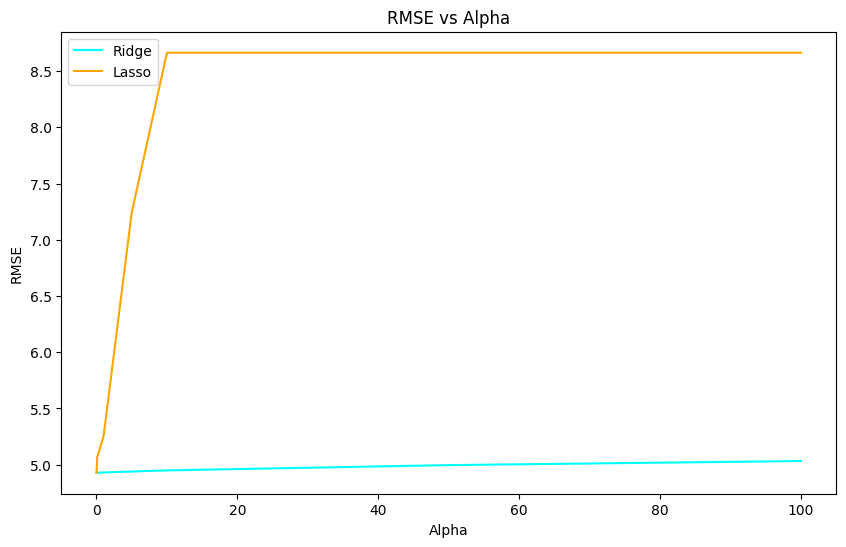

In [54]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_alpha,
             x="alpha",
             y="ridge_rmse",
             color="cyan",
             label="Ridge")
sns.lineplot(data=df_alpha,
             x="alpha",
             y="lasso_rmse",
             color="orange",
             label="Lasso")
plt.title("RMSE vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.legend()
plt.show()


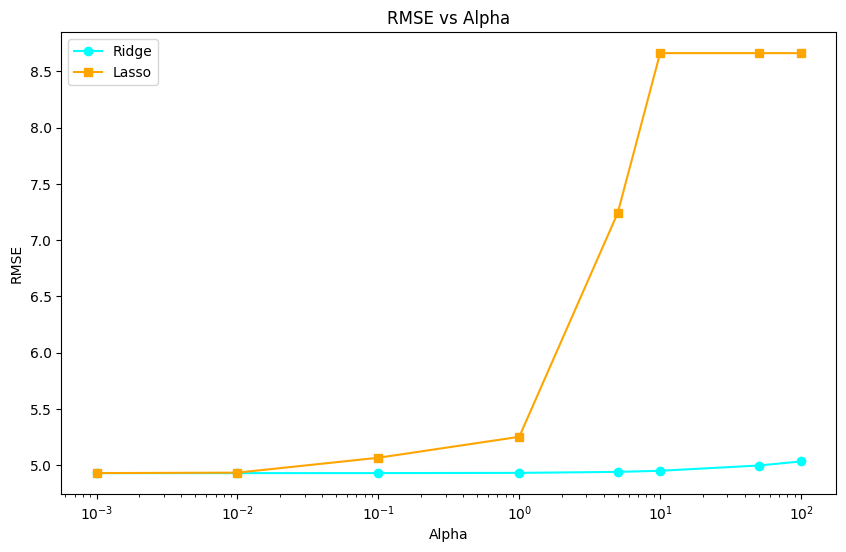

In [57]:
plt.figure(figsize=(10, 6))

plt.plot(df_alpha["alpha"], df_alpha["ridge_rmse"],"o-", color="cyan", label="Ridge")
plt.plot(df_alpha["alpha"], df_alpha["lasso_rmse"],"s-", color="orange", label="Lasso")

plt.xscale("log")

plt.title("RMSE vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.legend()
plt.show()

Interpretasi:


1. Perilaku Ridge Regression (Garis Cyan)
    - Sangat Stabil: Garis untuk Ridge hampir datar (horizontal) di sepanjang sumbu x dari nilai $\alpha = 10^{-3}$ hingga $10^2$.   
    - Artinya: Model Ridge sangat tahan terhadap perubahan nilai penalti (alpha). Bahkan ketika alpha diperbesar hingga 100, nilai RMSE hanya naik sedikit, menunjukkan bahwa model ini tidak mudah mengalami underfitting yang parah pada dataset ini.
    
    
2. Perilaku Lasso Regression (Garis Jingga)
    - Lonjakan Error (Divergensi): Pada nilai alpha kecil ($10^{-3}$ hingga $10^{-2}$), garis Lasso berhimpit dengan Ridge (RMSE rendah). Namun, begitu alpha melewati angka $10^{-1}$ dan terus naik ke $10^0$ hingga $10^1$, kurva RMSE melesat naik dengan curam (melonjak tajam) hingga akhirnya mendatar di titik tertinggi sekitar angka 8.6.   
    - Artinya: Penalti L1 pada Lasso bekerja jauh lebih agresif dalam membuang koefisien fitur. Ketika alpha terlalu besar, model kehilangan terlalu banyak informasi penting (over-regularization), yang langsung memicu lonjakan tingkat kesalahan prediksi (RMSE semakin besar).
    
💡 Kesimpulan Utama

Grafik ini memperlihatkan dengan sangat jelas perbedaan karakteristik antara penalti L2 (Ridge) dan L1 (Lasso):
  - Ridge lebih aman dan stabil terhadap rentang nilai alpha yang luas.   
  - Lasso membutuhkan rentang alpha yang sangat kecil (mendekati nol); jika salah memilih alpha yang terlalu besar, performa prediksinya akan langsung hancur.  

## Lasso Menyeleksi Fitur

Keunggulan unik Lasso:
- pada alpha tertentu, ia memaksa sebagian koefisien menjadi **tepat nol** — efektif "membuang" fitur tak penting (seleksi fitur otomatis).

Ridge hanya mengecilkan, tak pernah benar-benar nol.

In [60]:
ls_ = Lasso(alpha=1, max_iter=10000)
ls_.fit(X_train_scaled, y_train)

rgd_ = Ridge(alpha=1)
rgd_.fit(X_train_scaled, y_train)


koef = pd.DataFrame({
    "Ridge": rgd_.coef_,
    "Lasso": ls_.coef_,
}, index=X.columns).sort_values("Ridge")

In [61]:
n_nol = (koef["Lasso"].abs()< 1e-6).sum()

In [63]:
print(f"Jumlah fitur yang dibuat 0, oleh Lasso (alpha = 1): {n_nol} dari {len(koef)}")
koef.round(2)

Jumlah fitur yang dibuat 0, oleh Lasso (alpha = 1): 7 dari 13


,Ridge,Lasso
LSTAT,-3.60,-3.38
DIS,-3.05,-0.00
PTRATIO,-2.03,-1.22
NOX,-1.99,-0.00
TAX,-1.70,-0.00
CRIM,-0.99,-0.01
AGE,-0.18,-0.00
INDUS,0.25,-0.00
ZN,0.68,0.00
CHAS,0.72,0.04


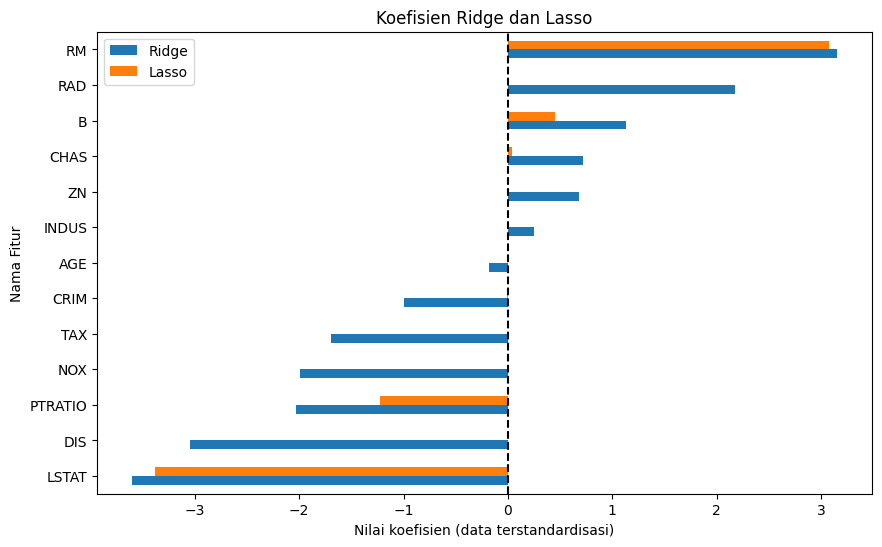

In [74]:
koef.plot(kind="barh", figsize=(10,6))
plt.title("Koefisien Ridge dan Lasso")
plt.xlabel("Nilai koefisien (data terstandardisasi)")
plt.ylabel("Nama Fitur")

plt.axvline(x=0, color="black", linestyle="--")
plt.show()

Interpretasi:
- Beberapa batang Lasso tepat di nol → fitur tersebut dianggap tidak berguna dan dibuang.
- Fitur yang bertahan (mis. `LSTAT`, `RM`, `PTRATIO`) adalah penentu harga paling kuat.
- Ridge mempertahankan semua fitur tapi mengecilkannya.


**Insight bisnis:**
- Lasso menghasilkan model lebih sederhana & mudah dijelaskan ke stakeholder.

## Kesimpulan dan Insight

- **Standardisasi wajib** sebelum regularisasi agar penalti adil antar fitur.
- **Ridge (L2)** mengecilkan semua koefisien → stabil saat fitur berkorelasi.
- **Lasso (L1)** menolkan sebagian koefisien → **seleksi fitur otomatis**, model ringkas.
- **alpha** harus disetel: terlalu kecil = overfit, terlalu besar = underfit.
- **Insight:** untuk model produksi yang mudah dijelaskan, Lasso menonjolkan
  segelintir fitur kunci (RM, LSTAT, PTRATIO) tanpa banyak kehilangan akurasi.